©2026. For information, contact Deloitte Tohmatsu Group.

# 📝 演習概要

この演習では、PyTorchを用いてTransformerアーキテクチャをフルスクラッチで実装します。Scaled Dot-Product Attention、Multi-Head Attention、位置エンコーディング、Encoder/Decoderの各コンポーネントを順に構築し、最終的に翻訳タスクでTransformerの動作を確認します。

# 事前準備

今回使用する「torhtext」ライブラリが正常に実行するように以下のセルを実行してください．

In [ ]:
!pip install -U torchtext==0.6.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.4 MB/s eta 0:00:00


[JDLAが策定しているバージョン](https://www.jdla.org/certificate/engineer/)に合わせるために、以下のセルの実行をお願いします．

（#コメントアウト されているものは必要ありません）

In [ ]:
%%capture
# !pip uninstall matplotlib -y
# !pip install matplotlib==3.9.4

# !pip uninstall opencv-python -y
# !pip install opencv-python==4.11.0.86

# !pip uninstall tensorflow -y
# !pip install tensorflow==2.19.0

!pip uninstall torch -y
!pip install torch==2.7.0

!pip uninstall torchvision -y
!pip install torchvision==0.22.0

# Transformer コード演習

---

目次
1.   Attentionについて
   * Scaled Dot-Product Attentionについて
   * マルチヘッドにする意味
   * 位置エンコーディング
   * その他
2.   Encoder部分
   * EncoderLayer
   * EncoderLayerを重ねてEncoder部分を定義
3.   Decoder部分
   * DecoderLayer
   * DecoderLayerを重ねてDecoderを定義
4.   Transformer
5.   使用するモデル、データセットの用意
   * 準備ファイル
   * IMDb(Internet Movie Database:映画のレビュー文章を集めたデータセット)をダウンロード
   * fastTextの英語学習済みモデルをダウンロード
   * IMDb(Internet Movie Database)のDataLoderを実装
   * 前処理と単語分割の関数を定義
   * DataLoaderの作成
   * ボキャブラリーの作成
6. Transformerの実装
   * Embedderモジュール
   * PositionalEncoderモジュール
   * TransformerBlockモジュール
   * ClassificationHeadモジュール
   * Transformerの実装
7.  Transformerの学習・推論、判定根拠の可視化を実装
   * DataLoaderとTransfermodelモデルの用意
   * 損失関数と最適化手法
   * 訓練と検証の関数の実装と実行
   * テストデータでの推論と判定根拠の可視化


#1. Attentionについて

Attentionメカニズムは、簡単にいえばつながりがあるデータの関係性を取ってくるためのメカニズムです。

## Scaled Dot-Product Attentionについて

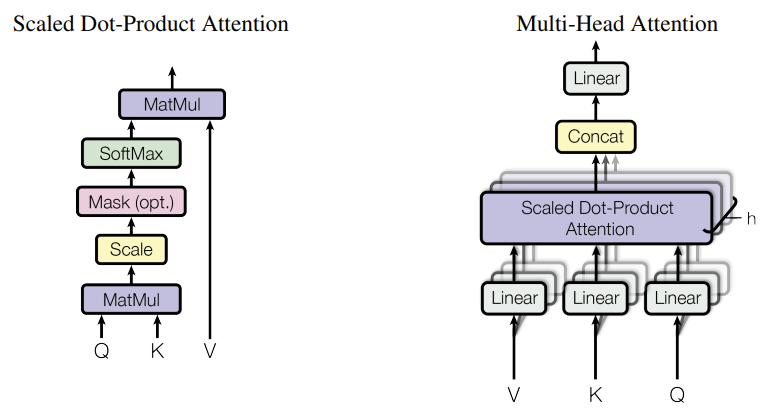

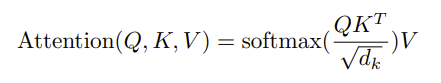



Q、K、Vは、それぞれサイズ（batch_size、seq_length、num_features）を持つ行列のバッチです。

Q, K同士を掛け合わせることで、どの要素を重視するかがわかります。これがAttentionです。
Attention配列はsoftmaxを使用して正規化されるため、すべての重みの合計が1になります。

そして、Attentionの情報を利用して、値（V）を取得します。





In [ ]:
from torch import Tensor
import torch.nn.functional as f

# torch.bmm()は、バッチごとに2次元×2次元の行列積を演算する関数です。
# 結果として、3次元×3次元の計算をしていることになります。
# （ブロードキャストせず、3次元×３次元専用の関数です）
def scaled_dot_product_attention(query: Tensor, key: Tensor, value:Tensor) -> Tensor :
  # QK.Tを計算します
  temp = query.bmm(key.transpose(1, 2))
  # スケーリングします
  scale = query.size(-1) ** 0.5
  # softmaxで正規化します
  softmax = f.softmax(temp / scale, dim = -1)
  # Vとかけあわせます
  return softmax.bmm(value)

In [ ]:
# Scaled Dot_Product Attentionを踏まえて、AttentionHeadを構築
import torch
from torch import nn

class AttentionHead(nn.Module):
  def __init__(self, dim_in:int, dim_k:int, dim_v:int):
    super().__init__()

    # クエリ、キー、バリューに対する線形変換を定義
    self.q = nn.Linear(dim_in, dim_k)   # クエリに対する線形変換
    self.k = nn.Linear(dim_in, dim_k)   # キーに対する線形変換
    self.v = nn.Linear(dim_in, dim_v)   # バリューに対する線形変換

  def forward(self, query: Tensor, key:Tensor, value:Tensor) -> Tensor:
    # クエリ、キー、バリューをそれぞれ線形変換した後、scaled_dot_product_attention関数に渡す
    return scaled_dot_product_attention(self.q(query), self.k(key), self.v(value))
    # 期待形状: 入出力とも (B, seq_len, d*)。seq_len（時系列長）は一致が前提


## マルチヘッドにする意味

1つのAttentionレイヤーを通すことで、データ内部の相関を学習していくことになります。ただし、それは限定的なものになります。

複数のレイヤーを通すことで、異なる観点についても学習していくことができます。そのことで、偏りのない相関関係を学習することができます。

In [ ]:
class MultiHeadAttention(nn.Module):
  def __init__(self, num_heads: int, dim_in: int, dim_k:int, dim_v: int):
    super().__init__()

    # 複数のAttentionHeadを含むリストを生成
    # これにより、複数のヘッドでのアテンション処理を並行して行う
    self.heads = nn.ModuleList(
        [AttentionHead(dim_in, dim_k, dim_v) for _ in range(num_heads)]
    )
    # 複数のヘッドからの出力を結合して、元の入力の次元に合わせるための線形変換を定義
    self.linear = nn.Linear(num_heads * dim_v, dim_in)

  def forward(self, query: Tensor, key: Tensor, value: Tensor) -> Tensor:

    # 各AttentionHeadでアテンション処理を行った結果を結合
    concatenated_heads = torch.cat([h(query, key, value) for h in self.heads], dim=-1)

    # 線形変換を通して最終的な出力を生成
    return self.linear(concatenated_heads)


# 位置エンコーディング

Attentionによって、データ内の相関関係を取得することはできますが、このとき時間的／空間的情報は考慮されていません。

文章などは文字の順番に大きな意味があるため、位置エンコーディングを通して、文字の順番を学習していく必要があります。

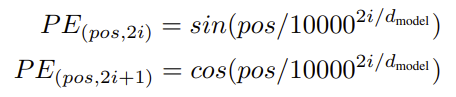

In [ ]:
def position_encoding(seq_len: int, dim_model: int, device: torch.device = torch.device('cpu')) -> Tensor:
  # シーケンスの長さに基づいて位置情報を生成
  pos = torch.arange(seq_len, dtype=torch.float, device=device).reshape(1, -1, 1)
  # モデルの次元数に基づいて次元情報を生成
  dim = torch.arange(dim_model, dtype=torch.float, device=device).reshape(1, 1, -1)

  # 位置エンコーディングの計算のための位相情報を生成
  phase = (pos / 1e4) ** (dim//dim_model)

  # 偶数次元はsin、奇数次元はcosを使用して位置エンコーディングを計算
  return torch.where(dim.long() % 2 == 0, torch.sin(phase), torch.cos(phase))

# その他

In [ ]:
# 順伝播層の仕組みを構築
def feed_forward(dim_input: int = 512, dim_feedforward: int = 2048) -> nn.Module:
  return nn.Sequential(
      nn.Linear(dim_input, dim_feedforward),
      nn.ReLU(),
      nn.Linear(dim_feedforward, dim_input)
  )

In [ ]:
# 正則化のための処理
class Residual(nn.Module):
  def __init__(self, sublayer: nn.Module, dimension:int, dropout: float = 0.1):
    super().__init__()
    self.sublayer = sublayer
    self.norm = nn.LayerNorm(dimension)  # Post-LN（x + Sublayer(x) の後にLayerNorm）
    self.dropout = nn.Dropout(dropout)  # 学習時のみ有効（model.train() 時）

  def forward(self, *tensors:Tensor) -> Tensor:
    return self.norm(tensors[-1] + self.dropout(self.sublayer(*tensors)))
    # 「最後の引数」を残差として使う設計。
    # 例: attention(src, src, src) を sublayer に渡す → 出力と src（=tensors[-1]）を加算

#2. Encoder部分

## EncoderLayer

In [ ]:
class TransformerEncoderLayer(nn.Module):
  def __init__(
      self,
      dim_model: int=512,
      num_heads: int = 6,
      dim_feedforward: int = 2048,
      dropout: float = 0.1
  ):
    super().__init__()

    # 1つのアテンションヘッドの次元数を計算
    dim_k = dim_v = dim_model // num_heads  # num_heads で割り切れる前提（割り切れないと次元不一致になる）

    # マルチヘッドアテンションを含む残差ブロックを初期化
    self.attention = Residual(
        MultiHeadAttention(num_heads, dim_model, dim_k, dim_v),
        dimension=dim_model,
        dropout=dropout
    )

    # フィードフォワードネットワークを含む残差ブロックを初期化
    self.feed_forward = Residual(
        feed_forward(dim_model, dim_feedforward),
        dimension=dim_model,
        dropout=dropout
    )

  def forward(self, src: Tensor) -> Tensor:
    # 入力に対してマルチヘッドアテンションを適用
    src = self.attention(src, src, src)  # 形状は (B, L, D)。同一テンソルを Q=K=V として自己注意

    # 残差接続とフィードフォワードネットワークを適用して出力を返す
    return self.feed_forward(src)  # (B, L, D) → (B, L, D)

## EncoderLayerを重ねてEncoder部分を定義

In [ ]:
class TransformerEncoder(nn.Module):
  def __init__(
      self,
      num_layers: int = 6,
      dim_model: int = 512,
      num_heads: int = 8,
      dim_feedforward: int = 2048,
      dropout: float = 0.1
  ):
    super().__init__()
    # EncoderLayerを重ねます
    self.layers = nn.ModuleList(
        [TransformerEncoderLayer(dim_model, num_heads, dim_feedforward, dropout) for _ in range(num_layers)])

  def forward(self, src: Tensor) -> Tensor:
    # データの情報を取得します
    seq_len, dimension = src.size(1), src.size(2)
    # 位置情報を付与します
    src += position_encoding(seq_len, dimension)
    for layer in self.layers:
      src = layer(src)
    return src

#3. Decoder部分

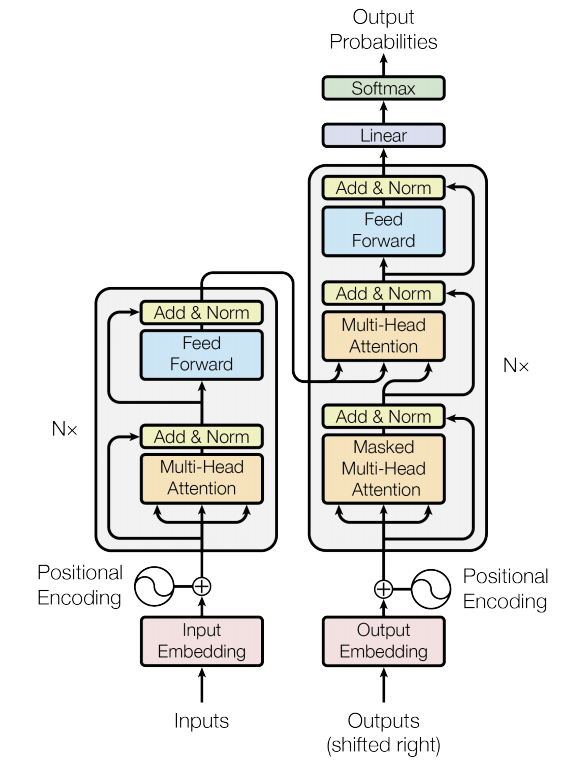

## DecoderLayer

In [ ]:
class TransformerDecoderLayer(nn.Module):
    def __init__(
        self,
        dim_model: int = 512,
        num_heads: int = 6,
        dim_feedforward: int = 2048,
        dropout: float = 0.1,
    ):
        super().__init__()

        # 1つのアテンションヘッドの次元数を計算
        dim_k = dim_v = dim_model // num_heads

        # マスクされたマルチヘッドアテンションを含む残差ブロックを初期化
        self.attention_1 = Residual(
            MultiHeadAttention(num_heads, dim_model, dim_k, dim_v),
            dimension=dim_model,
            dropout=dropout,
        )

        # エンコーダの出力をキー・バリューとして利用するためのマルチヘッドアテンションを含む残差ブロックを初期化
        self.attention_2 = Residual(
            MultiHeadAttention(num_heads, dim_model, dim_k, dim_v),
            dimension=dim_model,
            dropout=dropout,
        )

        # フィードフォワードネットワークを含む残差ブロックを初期化
        self.feed_forward = Residual(
            feed_forward(dim_model, dim_feedforward),
            dimension=dim_model,
            dropout=dropout,
        )

    def forward(self, tgt: Tensor, memory: Tensor) -> Tensor:

        # ターゲットに対してマスクされたマルチヘッドアテンションを適用
        tgt = self.attention_1(tgt, tgt, tgt)

        # エンコーダの出力（メモリ）とターゲットを用いてマルチヘッドアテンションを適用
        tgt = self.attention_2(memory, memory, tgt)

        # 残差接続とフィードフォワードネットワークを適用して出力を返す
        return self.feed_forward(tgt)

## DecoderLayerを重ねてDecoderを定義

In [ ]:
# Transformer Decoderクラスの定義
class TransformerDecoder(nn.Module):
    def __init__(
        self,
        num_layers: int = 6,          # デコーダ層の数（デフォルトは6）
        dim_model: int = 512,         # モデルの次元（デフォルトは512）
        num_heads: int = 8,           # マルチヘッドアテンションのヘッド数（デフォルトは8）
        dim_feedforward: int = 2048,  # フィードフォワードネットワークの次元（デフォルトは2048）
        dropout: float = 0.1,         # ドロップアウト率（デフォルトは0.1）
    ):
        super().__init__()
        # 複数のデコーダ層を格納するためのリスト
        self.layers = nn.ModuleList([
            TransformerDecoderLayer(dim_model, num_heads, dim_feedforward, dropout)
            for _ in range(num_layers)
        ])
        # 出力次元を調整するための線形変換
        self.linear = nn.Linear(dim_model, dim_model)

    def forward(self, tgt: Tensor, memory: Tensor) -> Tensor:
        # tgt: デコーダへの入力テンソル
        # memory: エンコーダからの出力テンソル

        # 入力テンソルのシーケンス長と次元を取得
        seq_len, dimension = tgt.size(1), tgt.size(2)  # 期待形状: tgt=(B, L, D)

        # ポジションエンコーディングを加算
        tgt += position_encoding(seq_len, dimension)

        # 各デコーダ層に入力テンソルとメモリテンソルを渡して順次処理
        for layer in self.layers:
            tgt = layer(tgt, memory)  # 期待形状は常に (B, L, D) を維持

        # 出力テンソルを線形変換し、ソフトマックス関数で正規化
        return torch.softmax(self.linear(tgt), dim=-1)


#4. Transformer

In [ ]:
# Transformerモデル全体を定義するクラス
class Transformer(nn.Module):
    def __init__(
        self,
        num_encoder_layers: int = 6,     # エンコーダ層の数（デフォルトは6）
        num_decoder_layers: int = 6,     # デコーダ層の数（デフォルトは6）
        dim_model: int = 512,            # モデルの次元（デフォルトは512）
        num_heads: int = 6,              # マルチヘッドアテンションのヘッド数（デフォルトは6）
        dim_feedforward: int = 2048,     # フィードフォワードネットワークの次元（デフォルトは2048）
        dropout: float = 0.1,            # ドロップアウト率（デフォルトは0.1）
        activation: nn.Module = nn.ReLU(),  # 活性化関数（デフォルトはReLU）
    ):
        super().__init__()
        # エンコーダを初期化
        self.encoder = TransformerEncoder(
            num_layers=num_encoder_layers,
            dim_model=dim_model,
            num_heads=num_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )
        # デコーダを初期化
        self.decoder = TransformerDecoder(
            num_layers=num_decoder_layers,
            dim_model=dim_model,
            num_heads=num_heads,  # EncoderとDecoderのヘッド数が一致
            dim_feedforward=dim_feedforward,
            dropout=dropout,
        )

    def forward(self, src: Tensor, tgt: Tensor) -> Tensor:
        # src: エンコーダへの入力テンソル
        # tgt: デコーダへの入力テンソル

        # エンコーダの出力を取得
        memory = self.encoder(src)  # 期待: src=(B, Ls, D) → memory=(B, Ls, D)
        # デコーダの出力を取得
        output = self.decoder(tgt, memory)  # 期待: tgt=(B, Lt, D) → output=(B, Lt, D)
        return output

In [ ]:
src = torch.rand(64, 16, 512)  # 形状: (バッチ=64, 長さ=16, 次元=512)
tgt = torch.rand(64, 16, 512)  # 形状: (バッチ=64, 長さ=16, 次元=512)
out = Transformer()(src, tgt)
print(out.shape)  # 期待: torch.Size([64, 16, 512])

torch.Size([64, 16, 512])


#5. 使用するモデル、データセットの用意

## 準備ファイル

In [ ]:
import os
import urllib.request
import zipfile
import tarfile

In [ ]:
# フォルダ「data」が存在しない場合に作成する
data_dir = "./data/"
if not os.path.exists(data_dir):
    os.mkdir(data_dir)

# IMDb(Internet Movie Database:映画のレビュー文章を集めたデータセット)をダウンロード

http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    

In [ ]:
# IMDbをダウンロード

url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
save_path = "./data/aclImdb_v1.tar.gz"
if not os.path.exists(save_path):
    urllib.request.urlretrieve(url, save_path)

In [ ]:
# './data/aclImdb_v1.tar.gz'の解凍

# tarファイルを読み込み
tar = tarfile.open('./data/aclImdb_v1.tar.gz')
tar.extractall('./data/')  # 解凍
tar.close()  # ファイルをクローズ

# フォルダ「data」内にフォルダ「aclImdb」というものができます。

/tmp/ipython-input-502538240.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall('./data/')  # 解凍


## fastTextの英語学習済みモデルをダウンロード

ボキャブラリー作成のために必要となる。

In [ ]:
# fastTextの公式の英語学習済みモデル（650MB）をダウンロード
url = "https://dl.fbaipublicfiles.com/fasttext/vectors-english/wiki-news-300d-1M.vec.zip"
save_path = "./data/wiki-news-300d-1M.vec.zip"
if not os.path.exists(save_path):
    urllib.request.urlretrieve(url, save_path)


In [ ]:
# フォルダ「data」内の「/wiki-news-300d-1M.vec.zip」を解凍する

Zip = zipfile.ZipFile("./data/wiki-news-300d-1M.vec.zip")
Zip.extractall("./data/")  # ZIPを解凍
Zip.close()  # ZIPファイルをクローズ

# フォルダ「data」内にフォルダ「wiki-news-300d-1M.vec」ができているかを確認する


## **IMDb(Internet Movie Database)のDataLoderを実装**

** IMDbデータセットをtsv形式に変換する **

tsv形式とは、１行がひとつのdataを示し、そのなかでテキストとラベルが記載され、それらをタブで区切ったファイル。

In [ ]:
# tsv形式のファイルにする
import glob
import os
import io
import string

# 訓練データのtsvファイルを作成する。
f = open('./data/IMDb_train.tsv', 'w')

# ポジティブデータ
path = './data/aclImdb/train/pos/'
for fname in glob.glob(os.path.join(path, '*.txt')):
  with io.open(fname, 'r', encoding='utf-8') as ff:
    text = ff.readline()  # 1行目のみ読み込み。

    # タブがあれば消す
    text = text.replace('\t', ' ')

    # テキストとラベルを記載し、タグで区切ったファイルにする
    text = text +'\t'+'1'+'\t'+'\n'
    f.write(text)

# ネガティブデータ
path = '.data/aclImdb/train/neg/'
for fname in glob.glob(os.path.join(path, '*.txt')):
  with io.open(fname, 'r', encoding='utf-8') as ff:
    text = ff.readline()

    # タブがあれば消す
    text = text.replace('\t', ' ')

    # テキストとラベルを記載し、タグで区切ったファイルにする。
    text = text+'\t'+'0'+'\t'+'\n'
    f.write(text)

f.close()

In [ ]:
#　テストデータの作成

f = open( './data/IMDb_test.tsv', 'w')

# ポジティブデータ
path = './data/aclImdb/test/pos/'
for fname in glob.glob(os.path.join(path, '*.txt')):
   with io.open(fname, 'r', encoding='utf-8') as ff:
     text = ff.readline()

     # タブがあれば消す
     text = text.replace('\t', ' ')

     # テキストとラベルを記載し、タグで区切ったファイルにする
     text = text+'\t'+'1'+'\t'+'\n'
     f.write(text)

# ネガティブデータ
path = './data/aclIMdb/test/neg/'
for fname in glob.glob(os.path.join(path, '*.txt')):
  with io.open(fname, 'r', encoding='utf-8') as ff:
    text = ff.readline()

    # タブがあれば消す
    text = text.replace('\t', ' ')

    # テキストとラベルを記載し、タグで区切ったファイルにする。
    text = text+'\t'+'0'+'\t'+'\n'
    f.write(text)

f.close()


##前処理と単語分割の関数を定義

前処理では、改行コード<br />を除去し、ピリオドとカンマ以外の記号をスペースに変えて最終的に除去する。

単語分割では、簡易的に半角スペースで単語を分割することにする。

In [ ]:
# 前処理と単語分割を一緒にした関数tokenizer_with_preprocessingを定義する
import string
import re

# 以下の記号はスペースに置き換える（カンマ、ピリオドを除く）
# punctuationとは日本語で句点という意味
print('区切り文字：', string.punctuation)
# !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~

# 前処理

def preprocessing_text(text):
  # 改行コードを消去
  text = re.sub('<br />', '', text)

  # カンマ、ピリオド以外の記号をスペースに置換:
  for p in string.punctuation:
    if (p == '.') or (p == ','):
      continue
    else:
      text = text.replace(p, ' ')

  #ピリオドなどの前後にはスペースををいれておく
  text = text.replace('.', ' . ')
  text = text.replace(',', ' , ')

  return text

# 分かち書き（今回はデータが英語のため、簡易的にスペースで区切る）
def tokenizer_punctuation(text):
  return text.strip().split()  # ホワイトスペースsplitの簡易トークナイザ

# 前処理と分かち書きをまとめた関数を定義
def tokenizer_with_preprocessing(text):
  text = preprocessing_text(text)
  ret = tokenizer_punctuation(text)
  return ret

# 動作を確認する
print(tokenizer_with_preprocessing('I like cats.'))


区切り文字： !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['I', 'like', 'cats', '.']


##DataLoaderの作成

tsvファイルを読み込んだ時に、各行のTEXTとLABELに実施する処理をtorchtext.data.Fieldで定義する。

In [ ]:
# データを読み込んだ時に、読み込んだ内容に対して行う処理を定義する
import torchtext
from torchtext import data

# 文章とラベルの両方を用意する
max_length = 256

#init_tokenでは、通常文頭には<bos>(begining of sentence)を入れるが今回はクラス分類のため<cls>になっている。
#eos_tokenでは、全部の文章の文末に<eos>(end of sentence)をいれる。
TEXT = torchtext.data.Field(sequential=True,
                            tokenize=tokenizer_with_preprocessing,
                            use_vocab=True,
                            lower=True,
                            include_lengths=True,
                            batch_first=True,
                            fix_length=max_length,
                            init_token='<cls>',
                            eos_token='<eos>')

LABEL = torchtext.data.Field(sequential=False, use_vocab=False)


In [ ]:
# Datasetを作成する

# フォルダ「data」から各tsvファイルを読み込む
train_val_ds, test_ds = torchtext.data.TabularDataset.splits(
    path= './data/',
    train='IMDb_train.tsv',
    test='IMDb_test.tsv',
    format='tsv',
    fields=[('Text', TEXT), ('Label', LABEL)]
)

# 動作確認
print('訓練および検証のデータ数', len(train_val_ds))
print('１つ目の訓練および検証のデータ', vars(train_val_ds[0]))

訓練および検証のデータ数 12500
１つ目の訓練および検証のデータ {'Text': ['in', 'order', 'to', 'rate', 'this', 'movie', 'fairly', 'you', 'have', 'to', 'think', 'about', 'the', 'genre', 'it', 's', 'supposed', 'to', 'be', 'children', 's', '.', 'they', 'had', 'more', 'guidelines', 'to', 'follow', 'in', 'order', 'to', 'make', 'this', 'movie', 'meaning', 'it', 'could', 'not', 'get', 'away', 'with', 'some', 'of', 'the', 'humor', 'and', 'or', 'language', 'from', 'the', '1st', 'taking', 'all', 'that', 'in', 'this', 'movie', 'was', 'fun', 'and', 'enjoyable', 'to', 'watch', '.', 'sequels', 'usually', 'make', 'me', 'nervous', ',', 'however', 'this', 'one', 'did', 'pretty', 'well', 'for', 'itself', '.', 'knowing', 'that', 'it', 'didn', 't', 'have', 'the', 'star', 'power', 'of', 'fraiser', 'as', 'george', 'they', 'capitalized', 'on', 'the', 'humor', 'and', 'i', 'believe', 'showeman', 'did', 'pretty', 'well', 'as', 'the', 'lead', '.', 'the', 'plot', 'being', 'easy', 'to', 'follow', 'and', 'maybe', 'campy', 'at', 'times', 'fits'

In [ ]:
# 訓練および検証のデータセットを訓練と検証のデータセットにそれぞれ分割する
import random

# torchtext.data.Dataset の split関数で訓練データとvalidationデータをわける
train_ds, val_ds = train_val_ds.split(split_ratio=0.8, random_state=random.seed(1234))

# 動作確認
print('訓練データの数', len(train_ds))
print('検証データの数', len(val_ds))
print('１つ目の訓練データ', vars(train_ds[0]))


訓練データの数 10000
検証データの数 2500
１つ目の訓練データ {'Text': ['in', 'one', 'of', 'neil', 'simon', 's', 'best', 'plays', '.', 'creaky', ',', 'cranky', 'ex', 'vaudeville', 'stars', 'played', 'by', 'walter', 'matthau', 'and', 'george', 'burns', 'are', 'teaming', 'up', 'for', 'a', 'tv', 'comedy', 'special', '.', 'the', 'problem', 'is', 'they', 'haven', 't', 'even', 'seen', 'each', 'other', 'in', 'over', 'a', 'decade', '.', 'full', 'of', 'zippy', 'one', 'liners', 'and', 'inside', 'showbiz', 'jokes', ',', 'this', 'story', 'flies', 'along', 'with', 'a', 'steady', 'stream', 'of', 'humor', '.', 'good', 'work', 'also', 'by', 'richard', 'benjamin', 'as', 'the', 'harried', 'nephew', ',', 'rosetta', 'lenoire', 'as', 'the', 'nurse', ',', 'and', 'howard', 'hesseman', 'as', 'the', 'tv', 'commercial', 'director', '.', 'steve', 'allen', 'and', 'phyllis', 'diller', 'appear', 'as', 'themselves', '.', 'trivia', 'note', 'the', 'opening', 'montage', 'contains', 'footage', 'from', 'hollywood', 'revue', 'of', '1929', 'and', 

##ボキャブラリーの作成

単語の分散表現を用いたボキャブラリーを作成する。

In [ ]:
#torchtextで単語ベクトルとして英語学習ずみモデルを読み込む
from torchtext.vocab import Vectors

english_fasttext_vectors = Vectors(name='data/wiki-news-300d-1M.vec')
# Vectors はローカルパスを読む。

# 単語ベクトルの中身を確認する
print('1単語を表現する次元数：', english_fasttext_vectors.dim)
print('単語数：', len(english_fasttext_vectors.itos))

100%|██████████| 999994/999994 [02:04<00:00, 8053.80it/s]


1単語を表現する次元数： 300
単語数： 999994


In [ ]:
#ベクトル化したバージョンのボキャブラリーを作成する
TEXT.build_vocab(train_ds, vectors=english_fasttext_vectors, min_freq=10)
# min_freq=10 未満の単語はUNKへ。

# ボキャブラリーのベクトルを確認する
print(TEXT.vocab.vectors.shape)#17916個の単語が300次元のベクトルで表現されている
TEXT.vocab.vectors

# ボキャブラリーの順番を確認する
TEXT.vocab.stoi

torch.Size([12284, 300])


defaultdict(<bound method Vocab._default_unk_index of <torchtext.vocab.Vocab object at 0x7e8830e19730>>,
            {'<unk>': 0,
             '<pad>': 1,
             '<cls>': 2,
             '<eos>': 3,
             'the': 4,
             '.': 5,
             ',': 6,
             'and': 7,
             'a': 8,
             'of': 9,
             'to': 10,
             'is': 11,
             'in': 12,
             'it': 13,
             'i': 14,
             'that': 15,
             'this': 16,
             's': 17,
             'as': 18,
             'with': 19,
             'for': 20,
             'was': 21,
             'but': 22,
             'film': 23,
             'movie': 24,
             'his': 25,
             'on': 26,
             'you': 27,
             'he': 28,
             'are': 29,
             'not': 30,
             't': 31,
             'one': 32,
             'have': 33,
             'be': 34,
             'all': 35,
             'by': 36,
             'who': 37,


In [ ]:
#DataLoaderの作成(torchtextの文脈では単純にiteraterと呼ばれる)
train_d1 = torchtext.data.Iterator(train_ds, batch_size=24, sort=False)
val_d1 = torchtext.data.Iterator(val_ds, batch_size=24, train=False, sort=False)
test_d1 = torchtext.data.Iterator(test_ds, batch_size=24, train=False, sort=False)

#動作確認　検証データのデータセットで確認
batch = next(iter(val_d1))
print(batch.Text)
print(batch.Label)

(tensor([[   2,  671,   32,  ...,    1,    1,    1],
        [   2,   16,   11,  ...,    1,    1,    1],
        [   2,    4,  644,  ..., 4238, 1803,    3],
        ...,
        [   2,  170,  492,  ...,   10,    0,    3],
        [   2, 5855, 1280,  ...,    1,    1,    1],
        [   2,   16,   21,  ...,    1,    1,    1]]), tensor([153,  73, 256, 256, 191, 200, 256, 197, 204, 256, 206, 163, 239, 114,
        164, 256, 197, 256, 256, 231, 135, 256, 200, 157]))
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


#6. Transformerの実装

Attention（Self-Attention）を用いたモデル。RNNやLSTMでは学習時間が非常に伸びてしまうという問題があったが、言語データの処理にもCNNや全結合層を使用することができないかという発想からうまれた方法。Attentionを利用することで、言語データにおいても単語同士の位置情報をうまく取り入れることができるようになった。

In [ ]:
# これまでのDataLoderをまとめる
import glob
import os
import io
import string
import re
import random
import spacy
import torchtext
from torchtext.vocab import Vectors  # fastTextの .vec を読む

def get_IMDb_DataLoaders_and_TEXT(max_length=256, batch_size=24):
    """IMDbのDataLoaderとTEXTオブジェクトを取得する。 """

    # 訓練データのtsvファイルを作成します
    f = open('./data/IMDb_train.tsv', 'w')

    path = './data/aclImdb/train/pos/'
    for fname in glob.glob(os.path.join(path, '*.txt')):
        with io.open(fname, 'r', encoding="utf-8") as ff:
            text = ff.readline()

            # タブがあれば消しておきます
            text = text.replace('\t', " ")

            text = text+'\t'+'1'+'\t'+'\n'  # フォーマット: 「テキスト<TAB>ラベル<TAB>空欄?」
            f.write(text)

    path = './data/aclImdb/train/neg/'
    for fname in glob.glob(os.path.join(path, '*.txt')):
        with io.open(fname, 'r', encoding="utf-8") as ff:
            text = ff.readline()

            # タブがあれば消す
            text = text.replace('\t', " ")

            text = text+'\t'+'0'+'\t'+'\n'
            f.write(text)

    f.close()

   # テストデータの作成
    f = open('./data/IMDb_test.tsv', 'w')

    path = './data/aclImdb/test/pos/'
    for fname in glob.glob(os.path.join(path, '*.txt')):
        with io.open(fname, 'r', encoding="utf-8") as ff:
            text = ff.readline()

            # タブがあれば消す
            text = text.replace('\t', " ")

            text = text+'\t'+'1'+'\t'+'\n'
            f.write(text)

    path = './data/aclImdb/test/neg/'
    for fname in glob.glob(os.path.join(path, '*.txt')):
        with io.open(fname, 'r', encoding="utf-8") as ff:
            text = ff.readline()

            # タブがあれば消す
            text = text.replace('\t', " ")

            text = text+'\t'+'0'+'\t'+'\n'
            f.write(text)
    f.close()

    def preprocessing_text(text):
        # 改行コードを消去
        text = re.sub('<br />', '', text)  # IMDbに含まれるHTML改行タグの除去

        # カンマ、ピリオド以外の記号をスペースに置換
        for p in string.punctuation:
            if (p == ".") or (p == ","):
                continue
            else:
                text = text.replace(p, " ")

        # ピリオドなどの前後にはスペースを入れておく
        text = text.replace(".", " . ")
        text = text.replace(",", " , ")
        return text

    # 分かち書き（今回はデータが英語で、簡易的にスペースで区切る）
    def tokenizer_punctuation(text):
        return text.strip().split()  # 単純な空白スプリット（サブワード分割等は行わない）


    # 前処理と分かち書きをまとめた関数を定義
    def tokenizer_with_preprocessing(text):
        text = preprocessing_text(text)
        ret = tokenizer_punctuation(text)
        return ret


    # データを読み込んだときに、読み込んだ内容に対して行う処理を定義します
    # max_length
    TEXT = torchtext.data.Field(sequential=True, tokenize=tokenizer_with_preprocessing, use_vocab=True,
                                lower=True, include_lengths=True, batch_first=True, fix_length=max_length, init_token="<cls>", eos_token="<eos>")
    LABEL = torchtext.data.Field(sequential=False, use_vocab=False)

    # フォルダ「data」から各tsvファイルを読み込みます
    train_val_ds, test_ds = torchtext.data.TabularDataset.splits(
        path= './data/', train='IMDb_train.tsv',
        test='IMDb_test.tsv', format='tsv',
        fields=[('Text', TEXT), ('Label', LABEL)])

    # torchtext.data.Datasetのsplit関数で訓練データとvalidationデータを分ける
    train_ds, val_ds = train_val_ds.split(
        split_ratio=0.8, random_state=random.seed(1234))  # 再現性のためseed固定

    # torchtextで単語ベクトルとして英語学習済みモデルを読み込みます
    english_fasttext_vectors = Vectors(name='data/wiki-news-300d-1M.vec')

    # ベクトル化したバージョンのボキャブラリーを作成します
    TEXT.build_vocab(train_ds, vectors=english_fasttext_vectors, min_freq=10)
    # min_freq=10 未満の語はUNK。語彙数が多いと TEXT.vocab.vectors のサイズが巨大化

    # DataLoaderを作成します（torchtextの文脈では単純にiteraterと呼ばれています）
    train_dl = torchtext.data.Iterator(
        train_ds, batch_size=batch_size, train=True)

    val_dl = torchtext.data.Iterator(
        val_ds, batch_size=batch_size, train=False, sort=False)

    test_dl = torchtext.data.Iterator(
        test_ds, batch_size=batch_size, train=False, sort=False)

    return train_dl, val_dl, test_dl, TEXT


## Embedderモジュール

単語IDに応じて単語ベクトルを与える役割をもつ。

In [ ]:
#Embedderモジュールの実装（Embedderモジュールは単語IDに応じて単語ベクトルを与える役割をする）
import torch.nn as nn

class Embedder(nn.Module):

  def __init__(self, text_embedding_vectors):
    super(Embedder, self).__init__()

    # freeze==Trueによりバックプロパゲーションで更新されず変化しなくなる
    self.embeddings = nn.Embedding.from_pretrained(
        embeddings=text_embedding_vectors,
        freeze=True
    )  # 事前学習済みベクトルをそのまま使う（学習で更新しない）

  def forward(self, x):
    x_vec = self.embeddings(x)

    return x_vec

In [ ]:
# 動作確認

train_dl, val_dl, test_dl, TEXT = get_IMDb_DataLoaders_and_TEXT(max_length=256, batch_size=24)

#ミニバッチの用意
batch = next(iter(train_dl))  # batch.Text は (tensor, lengths) タプル

#モデル構築
net1 = Embedder(TEXT.vocab.vectors)

#入出力
x = batch.Text[0]  # 語IDテンソル (B, L)
x1 = net1(x)  #単語をベクトルにする

print('入力のテンソルサイズ：', x.shape)
print('出力のテンソルサイズ：', x1.shape)

入力のテンソルサイズ： torch.Size([24, 256])
出力のテンソルサイズ： torch.Size([24, 256, 300])


## PositionalEncoderモジュール

単語の位置と分散表現の次元が一意に決まる位置情報テンソルを足し算している。

In [ ]:
#PositionalEncoderモジュールの実装
#入力された単語の位置を示すベクトル情報を付加する
import math

class PositionalEncoder(nn.Module):
  def __init__(self, d_model=300, max_seq_len=256):
    super().__init__()

    self.d_model = d_model  #単語ベクトルの次元数

    # 単語の順番（pos）と埋め込みベクトルの次元の位置(i)によって一意に定まる値の表をpeとして作成
    pe = torch.zeros(max_seq_len, d_model)

    #GPUが使える場合、GPUに送る
    #device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    #pe = pe.to(device)

    for pos in range(max_seq_len):
      for i in range(0, d_model, 2):
        pe[pos, i] = math.sin(pos/(10000 ** ((2 * i) / d_model)))
        pe[pos, i + 1] = math.cos(pos/(10000 ** ((2 * i)/d_model)))

    #表peの先頭に、ミニバッチ次元となる次元をたす
    self.pe = pe.unsqueeze(0)  # 形状: (1, L, D)

    # 勾配を計算しないようにする
    self.pe.requires_grad = False  # 学習で更新しない定数

  def forward(self, x):

    # 入力ｘとPositional Encodingを足し算する
    # xがpeよりも小さいので、大きくする
    ret = math.sqrt(self.d_model)*x + self.pe  # x: (B,L,D)、pe: (1,L,D) でブロードキャスト加算
    return ret

In [ ]:
# 動作確認
import torch

# モデル構築
net1 = Embedder(TEXT.vocab.vectors)
net2 = PositionalEncoder(d_model=300, max_seq_len=256)

#入出力
x = batch.Text[0]
x1 = net1(x)  #単語をベクトルにする
x2 = net2(x1)

print('入力のテンソルサイズ：', x1.shape)
print('出力のテンソルサイズ：', x2.shape)


入力のテンソルサイズ： torch.Size([24, 256, 300])
出力のテンソルサイズ： torch.Size([24, 256, 300])


## TransformerBlockモジュール

TransformerBlockモジュールは、LayerNormalization、Dropout、AttentionとFeedForwardから構成されている。

In [ ]:
#Attentionの実装
#本来TransformerはマルチヘッドAttentionだが、わかりやすさのためにシングルヘットとしている。
import torch.nn.functional as F

class Attention(nn.Module):
  def __init__(self, d_model=300):
    super().__init__()

    #全結合層で特徴量を変換する
    self.q_linear = nn.Linear(d_model, d_model)
    self.v_linear = nn.Linear(d_model, d_model)
    self.k_linear = nn.Linear(d_model, d_model)

    #出力時に使用する全結合層
    self.out = nn.Linear(d_model, d_model)

    # Attentionの大きさ調整の変数
    self.d_k = d_model

  def forward(self, q, k, v, mask):
    #全結合層で特徴量を変換
    k = self.k_linear(k)
    q = self.q_linear(q)
    v = self.v_linear(v)

    # Attentionの値を計算する
    # 各値を足し算すると大きくなりすぎるので、root(d_k)で割って調整
    weights = torch.matmul(q, k.transpose(1, 2)) / math.sqrt(self.d_k)  # (B,L,L)

    # ここでmaskを計算
    mask = mask.unsqueeze(1)  # (B,1,L) に拡張（キー系列側に適用）
    weights = weights.masked_fill(mask == 0, -1e9)  # PAD位置に大負数を入れて無効化

    # softmaxで規格化する
    normlized_weights = F.softmax(weights, dim=-1)

    # AttentionをValueと掛け算
    output = torch.matmul(normlized_weights, v)  # (B,L,D)

    # 全結合層で特徴量を変換
    output = self.out(output)

    return output, normlized_weights


In [ ]:
# FeedForwardの実装
# Attention層から出力を単純に全結合層2つで特徴量を変換するだけのユニット
class FeedForward(nn.Module):
  def __init__(self, d_model, d_ff=1024, dropout=0.1):
    super().__init__()

    self.linear_1 = nn.Linear(d_model, d_ff)
    self.dropout = nn.Dropout(dropout)
    self.linear_2 = nn.Linear(d_ff, d_model)

  def forward(self, x):
    x = self.linear_1(x)
    x = self.dropout(F.relu(x))
    x = self.linear_2(x)
    return x


In [ ]:
# TransformerBlockの実装
class TransformerBlock(nn.Module):
  def __init__(self, d_model, dropout=0.1):
    super().__init__()

    # LayerNormalization層
    self.norm_1 = nn.LayerNorm(d_model)
    self.norm_2 = nn.LayerNorm(d_model)

    # Attention層
    self.attn = Attention(d_model)

    # Attentionのあとの全結合層2つ
    self.ff = FeedForward(d_model)

    # Dropout
    self.dropout_1 = nn.Dropout(dropout)
    self.dropout_2 = nn.Dropout(dropout)

  def forward(self, x, mask):
    #正則化とAttention
    x_normlized = self.norm_1(x)
    output, normlized_weights = self.attn(x_normlized, x_normlized, x_normlized,  mask)
    x2 = x + self.dropout_1(output)  # 残差

    #正規化と全結合層
    x_normlized2 = self.norm_2(x2)
    output = x2 + self.dropout_2(self.ff(x_normlized2))  # 残差

    return output, normlized_weights

In [ ]:
# 動作確認

# モデル構築
net1 = Embedder(TEXT.vocab.vectors)
net2 = PositionalEncoder(d_model=300, max_seq_len=256)
net3 = TransformerBlock(d_model=300)

# maskの作成
x = batch.Text[0]
input_pad = 1   #単語のIDにおいて、'<pad>':１のため
input_mask = (x != input_pad)
print(input_mask[0])

# 入出力
x1 = net1(x)  #単語をベクトルにする
x2 = net2(x1)  #Position情報を足し算する
x3, normlized_weights = net3(x2, input_mask)  #self-Attentionで特徴量を変化

print('入力のテンソルサイズ：', x2.shape)
print('出力のテンソルサイズ：', x3.shape)
print('Attentionのサイズ:', normlized_weights.shape)

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

## ClassificationHeadモジュール

ポジティブ、ネガティブの値を二次元で出力させる。

なお、Transformerにおいて先頭単語の特徴量にクラス分類のための情報が自然と集まるわけではない。先頭単語の特徴量を使用して分類し、その損失をバックプロパゲーションしてネットワーク全体を学習させることで、先頭単語の特徴量が自然と文章のポジティブ、ネガティブを判定する特徴量になるように学習されている。

In [ ]:
#TransformerBlockの出力を使用し、最後にクラス分類させる
class ClassificationHead(nn.Module):
  def __init__(self, d_model=300, output_dim=2):
    super().__init__()

    #全結合層
    self.linear = nn.Linear(d_model, output_dim)  #outputはポジ・ネガの2つ

    #重み初期化処理
    nn.init.normal_(self.linear.weight, std=0.02)
    nn.init.normal_(self.linear.bias, 0)

  def forward(self, x):
    x0 = x[:, 0, :]  #各ミニバッチの各文の先頭の単語の特徴量（300次元）を取り出す
    out = self.linear(x0)

    return out


### Transfomerの実装

In [ ]:
class TransformerClassification(nn.Module):
  def __init__(self, text_embedding_vectors, d_model=300, max_seq_len=256, output_dim=2):
    super().__init__()

    # モデル構築
    self.net1 = Embedder(text_embedding_vectors)
    self.net2 = PositionalEncoder(d_model=d_model, max_seq_len=max_seq_len)
    self.net3_1 = TransformerBlock(d_model=d_model)
    self.net3_2 = TransformerBlock(d_model=d_model)
    self.net4 = ClassificationHead(output_dim=output_dim, d_model=d_model)

  def forward(self, x, mask):
    x1 = self.net1(x)     # 単語をベクトルにする
    x2 = self.net2(x1)    # Position情報を足し算する
    x3_1, normlized_weights_1 = self.net3_1(x2, mask)    # self-Attentionで特徴量を変換する
    x3_2, normlized_weights_2 = self.net3_2(x3_1, mask)  # self-Attentionで特徴量を変換する
    x4 = self.net4(x3_2)  # 最終出力の０単語目を使用して、分類0-1のスカラーを出力

    return x4, normlized_weights_1, normlized_weights_2

In [ ]:
# 動作確認

# ミニバッチの用意
batch = next(iter(train_d1))

# モデル構築
net = TransformerClassification(text_embedding_vectors=TEXT.vocab.vectors, d_model=300, max_seq_len=256, output_dim=2)

# 入出力
x= batch.Text[0]
input_mask = (x != input_pad)
out, normlized_weights_1, normlized_weights_2 = net(x, input_mask)

print('出力のテンソルサイズ：', out.shape)
print('出力のテンソルのsigmoid：', F.softmax(out, dim=1))

出力のテンソルサイズ： torch.Size([24, 2])
出力のテンソルのsigmoid： tensor([[0.1263, 0.8737],
        [0.1285, 0.8715],
        [0.1368, 0.8632],
        [0.1348, 0.8652],
        [0.1352, 0.8648],
        [0.1088, 0.8912],
        [0.1420, 0.8580],
        [0.1174, 0.8826],
        [0.1226, 0.8774],
        [0.1260, 0.8740],
        [0.1174, 0.8826],
        [0.1519, 0.8481],
        [0.1477, 0.8523],
        [0.1356, 0.8644],
        [0.1246, 0.8754],
        [0.1211, 0.8789],
        [0.1118, 0.8882],
        [0.1128, 0.8872],
        [0.1054, 0.8946],
        [0.1215, 0.8785],
        [0.1142, 0.8858],
        [0.1150, 0.8850],
        [0.1323, 0.8677],
        [0.1289, 0.8711]], grad_fn=<SoftmaxBackward0>)


##7. Transformerの学習・推論、判定根拠の可視化を実装

### DataLoaderとTransfermodelモデルの用意

In [ ]:
#学習の際、GPUを利用するために一部を変更したPositionalEncoderを再実装する。

#PositionalEncoderモジュールの実装
#入力された単語の位置を示すベクトル情報を付加する
import math

class PositionalEncoder(nn.Module):
  def __init__(self, d_model=300, max_seq_len=256):
    super().__init__()

    self.d_model = d_model  #単語ベクトルの次元数

    # 単語の順番（pos）と埋め込みベクトルの次元の位置(i)によって一意に定まる値の表をpeとして作成
    pe = torch.zeros(max_seq_len, d_model)

    #GPUが使える場合、GPUに送る
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    pe = pe.to(device)

    for pos in range(max_seq_len):
      for i in range(0, d_model, 2):
        pe[pos, i] = math.sin(pos/(10000 ** ((2 * i) / d_model)))
        pe[pos, i + 1] = math.cos(pos/(10000 ** ((2 * i)/d_model)))

    #表peの先頭に、ミニバッチ次元となる次元をたす
    self.pe = pe.unsqueeze(0)

    # 勾配を計算しないようにする
    self.pe.requires_grad = False

  def forward(self, x):

    # 入力ｘとPositional Encodingを足し算する
    # xがpeよりも小さいので、大きくする
    ret = math.sqrt(self.d_model)*x + self.pe
    return ret

In [ ]:
# 読み込み
train_d1, val_d1, test_d1, TEXT = get_IMDb_DataLoaders_and_TEXT(max_length=256, batch_size=64)

# 辞書オブジェクトにまとめる
dataloaders_dict = {'train': train_d1, 'val': val_d1}

# モデル構築
net = TransformerClassification(text_embedding_vectors=TEXT.vocab.vectors, d_model=300, max_seq_len=256, output_dim=2)

# ネットワークの初期化を定義
def weights_init(m):
  classname = m.__class__.__name__
  if classname.find('Linear') != -1:
    # Linear層の初期化
    nn.init.kaiming_normal_(m.weight)
    if m.bias is not None:
      nn.init.constant_(m.bias, 0.0)

#訓練モードに設定
net.train()

# TransformerBlockモジュールを初期化実行
net.net3_1.apply(weights_init)
net.net3_2.apply(weights_init)

print('ネットワーク設定完了')

ネットワーク設定完了


## 損失関数と最適化手法

In [ ]:
#損失関数の設定
from torch import optim

#nn.LogSoftmax()を計算してからnn.NLLLoss(negative log likelihood loss)を計算
criterion = nn.CrossEntropyLoss()

# 最適化手法の設定
learning_rate = 2e-5
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

## 訓練と検証の関数の実装と実行

In [ ]:
# モデルを学習させる関数を作成

def train_model(net, dataloaders_dict, criterion, optimizer, num_epochs):

  #GPUが使えるかを確認
  device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
  print('使用デバイス：', device)
  print('-----start-----')
  #ネットワークをGPUへ
  net.to(device)

  #ネットワークがある程度固定であれば、高速化させる
  torch.backends.cudnn.benchmark = True

  # epochのループ
  for epoch in range(num_epochs):
    # epochepochごとの訓練と検証のループ
    for phase in ['train', 'val']:
      if phase == 'train':
        net.train()  #モデルを訓練モードにする
      else:
        net.eval()  #モデルを検証モードにする

      epoch_loss = 0.0  # epochの損失和
      epoch_corrects = 0  # epochの正解数

      #データローダーからミニバッチを取り出すループ
      for batch in (dataloaders_dict[phase]):
        # batchはTextとLabelの辞書オブジェクト

        # GPUが使えるならGPUにデータを送る
        inputs = batch.Text[0].to(device)##文章
        labels = batch.Label.to(device)#ラベル

        # optimizerを初期化
        optimizer.zero_grad()

        #順伝播(forward)計算
        with torch.set_grad_enabled(phase == 'train'):

          # mask作成
          input_pad = 1 #単語のIDにおいて、'<pad>:1のため
          input_mask = (inputs != input_pad)

          # Transfomerに入力
          outputs, _, _ = net(inputs, input_mask)
          loss = criterion(outputs, labels) #損失を計算

          _, preds = torch.max(outputs, 1) #ラベルを予測

          # 訓練時はバックプロパゲーション
          if phase == 'train':
            loss.backward()
            optimizer.step()

          # 結果の計算
          # lossの合計を更新
          epoch_loss += loss.item() * inputs.size(0)
          # 正解数の合計を更新
          epoch_corrects += torch.sum(preds == labels.data)

      # epochごとのlossと正解率
      epoch_loss = epoch_loss / len(dataloaders_dict[phase].dataset)
      epoch_acc = epoch_corrects.double()/ len(dataloaders_dict[phase].dataset)

      print('Epoch {}/{} | {:^5} | Loss: {:.4f} Acc: {:.4f}'.format(epoch+1, num_epochs, phase, epoch_loss, epoch_acc))

  return net

In [ ]:
# GPUを使用しているか、確認する。
import torch
torch.cuda.is_available()

True

In [ ]:
# 学習・検証を10回する
num_epochs = 10
net_trained = train_model(net, dataloaders_dict, criterion, optimizer, num_epochs=num_epochs)

使用デバイス： cuda:0
-----start-----
Epoch 1/10 | train | Loss: 0.5983 Acc: 0.6763
Epoch 1/10 |  val  | Loss: 0.4433 Acc: 0.8014
Epoch 2/10 | train | Loss: 0.4387 Acc: 0.8006
Epoch 2/10 |  val  | Loss: 0.4147 Acc: 0.8130
Epoch 3/10 | train | Loss: 0.4085 Acc: 0.8159
Epoch 3/10 |  val  | Loss: 0.3860 Acc: 0.8266
Epoch 4/10 | train | Loss: 0.3897 Acc: 0.8245
Epoch 4/10 |  val  | Loss: 0.3758 Acc: 0.8354
Epoch 5/10 | train | Loss: 0.3746 Acc: 0.8341
Epoch 5/10 |  val  | Loss: 0.3685 Acc: 0.8392
Epoch 6/10 | train | Loss: 0.3639 Acc: 0.8381
Epoch 6/10 |  val  | Loss: 0.3655 Acc: 0.8404
Epoch 7/10 | train | Loss: 0.3553 Acc: 0.8435
Epoch 7/10 |  val  | Loss: 0.3771 Acc: 0.8374
Epoch 8/10 | train | Loss: 0.3452 Acc: 0.8506
Epoch 8/10 |  val  | Loss: 0.3542 Acc: 0.8454
Epoch 9/10 | train | Loss: 0.3389 Acc: 0.8543
Epoch 9/10 |  val  | Loss: 0.3499 Acc: 0.8472
Epoch 10/10 | train | Loss: 0.3341 Acc: 0.8569
Epoch 10/10 |  val  | Loss: 0.3459 Acc: 0.8516


## テストデータでの推論と判定根拠の可視化

In [ ]:
# device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

net_trained.eval() # モデルを検証モードにする
net_trained.to(device)

# epochの正解数
epoch_corrects = 0

for batch in (test_dl):
  # testデータのDataLoader
  # batchはTextとLabelの辞書オブジェクト

  # GPUが使えるならGPUにデータを送る
  # 文章
  inputs = batch.Text[0].to(device)
  # ラベル
  labels = batch.Label.to(device)

  #順伝播(forward)計算
  with torch.set_grad_enabled(False):

    # maskを作成
    input_pad = 1 # 単語のIDにおいて、'<pad>':1のため
    input_mask = (inputs != input_pad)

    # Transformerに入力
    outputs, _, _ = net_trained(inputs, input_mask)
    _, preds = torch.max(outputs, 1)# ラベルを予測

    # 結果の計算
    # 正解数の合計を更新
    epoch_corrects += torch.sum(preds == labels.data)

# 正解率
epoch_acc = epoch_corrects.double() / len(test_dl.dataset)

print('テストデータ{}個での正解率：{:.4f}'.format(len(test_dl.dataset), epoch_acc))

テストデータ25000個での正解率：0.8481


### Attentionの可視化で判定根拠を探る

In [ ]:
# HTMLを作成する関数を実装する
# Attentionの値が大きいと文字の背景が濃い赤になるhtmlを出力させる関数

def highlight(word, attn):
  html_color = '#%02X%02X%02X' % (255, int(255*(1 - attn)), int(255*(1 - attn)))
  return '<span style="background-color: {}"> {}</span>'.format(html_color, word)

def mk_html(index, batch, preds, normlized_weights_1, normlized_weights_2, TEXT):
  #HTMLデータを作成する

  # indexの結果を抽出
  # 文章
  sentence = batch.Text[0][index]
  # ラベル
  label = batch.Label[index]
  # 予測
  pred = preds[index]

  # indexのAttentionを抽出と規格化
  attens1 = normlized_weights_1[index, 0, :] # 0番目の<cls>のAttention
  attens1 /= attens1.max()

  attens2 = normlized_weights_2[index, 0, :] # 0番目の<cls>のAttention
  attens2 /= attens2.max()

  # ラベルと予測結果を文字に置き換え
  if label == 0:
    label_str = 'Negative'
  else:
    label_str = 'Positive'

  if pred == 0:
    pred_str = 'Negative'
  else:
    pred_str = 'Positive'

  # 表示用のHTMLを作成する
  html = '正解ラベル: {}<br>推論ラベル：{}<br><br>'.format(label_str, pred_str)

  # 1段目のAttention
  html += '[TransformerBlockの1段目のAttentionを可視化]<br>'
  for word, attn in zip(sentence, attens1):
    html += highlight(TEXT.vocab.itos[word], attn)
  html += '<br><br>'

  # 2段目のAttention
  html += '[TransformerBlockの２段目のAttentionを可視化]<br>'
  for word, attn in zip(sentence, attens2):
    html += highlight(TEXT.vocab.itos[word], attn)

  html += '<br><br>'

  return html

In [ ]:
from IPython.display import HTML

# Transformerで処理

# ミニバッチの用意
batch = next(iter(test_dl))

# GPUが使える場合はGPUに送る
inputs = batch.Text[0].to(device)
labels = batch.Label.to(device)

# maskを作成
input_pad = 1 # 単語のIDにおいて、'<pad>':1のため
input_mask = (inputs != input_pad)

# Transformerに入力
outputs, normlized_weights_1, normlized_weights_2 = net_trained(inputs, input_mask)
_, preds = torch.max(outputs, 1) #ラベルを予測

# 出力させたいデータ
index = 3
# HTMLの作成
html_output = mk_html(index, batch, preds, normlized_weights_1, normlized_weights_2, TEXT)

HTML(html_output)  #HTML形式で出力

In [ ]:
index = 23  # 出力させたいデータ
html_output = mk_html(index, batch, preds, normlized_weights_1, normlized_weights_2, TEXT)  # HTML作成
HTML(html_output)  # HTML形式で出力

## 🔧 実践問題1：因果マスク（Causal Mask）付きのAttentionを実装する

上のAttentionクラスではPADトークンに対するマスクを実装しましたが、
**デコーダのSelf-Attention**ではもう一つ重要なマスクが必要です。

デコーダは文を左から右に生成するため、位置 `t` のトークンは位置 `t+1` 以降の**未来のトークンを見てはいけません**。
これを防ぐのが**因果マスク（Causal Mask）**です。

```
系列長4の場合の因果マスク:
  [[1, 0, 0, 0],    ← 位置0は自分だけ見える
   [1, 1, 0, 0],    ← 位置1は0と1が見える
   [1, 1, 1, 0],    ← 位置2は0,1,2が見える
   [1, 1, 1, 1]]    ← 位置3は全て見える
```

0の位置（未来）に `-1e9`（≒−∞）を入れてからsoftmaxすると、その位置のAttention重みが0になります。

---

**問題：** 以下のコードの `______` を埋めて、因果マスクを生成し、Attentionに適用してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
PyTorchの <code>torch.tril()</code> は行列の<b>下三角部分</b>だけを残し、上三角を0にする関数です。
</blockquote>

</details>

<br/>


In [ ]:
import torch
import torch.nn.functional as F
import math

def create_causal_mask(seq_len):
    """因果マスクを生成: 下三角が1、上三角が0の行列"""
    # onesで全て1の行列を作り、trilで下三角だけ残す
    mask = torch.______(torch.ones(seq_len, ______))
    return mask  # shape: (seq_len, seq_len)


def causal_attention(query, key, value):
    """因果マスク付きScaled Dot-Product Attention"""
    # Q × K^T を計算
    scores = torch.matmul(query, key.______(-1, -2))  # (B, L, L)

    # スケーリング: √d_k で割る
    d_k = query.size(______)
    scores = scores / math.______(d_k)

    # 因果マスクを適用（未来の位置を-infにする）
    seq_len = query.size(1)
    mask = create_causal_mask(seq_len).to(query.device)
    scores = scores.masked_fill(mask == ______, -1e9)

    # Softmaxで正規化
    weights = F.softmax(scores, dim=______)

    # Attention重み × V
    return torch.matmul(weights, value), weights


# 動作確認
B, L, D = 2, 5, 8  # バッチ2, 系列長5, 次元8
q = torch.randn(B, L, D)
k = torch.randn(B, L, D)
v = torch.randn(B, L, D)

out, attn_weights = causal_attention(q, k, v)
print(f'出力: {out.shape}')  # (2, 5, 8)
print(f'Attention重み（1サンプル目）:')
print(attn_weights[0].detach().numpy().round(3))
# → 上三角が全て0.000になっていれば正解


<details><summary>解答例</summary>

```python
def create_causal_mask(seq_len):
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask

def causal_attention(query, key, value):
    scores = torch.matmul(query, key.transpose(-1, -2))
    d_k = query.size(-1)
    scores = scores / math.sqrt(d_k)
    seq_len = query.size(1)
    mask = create_causal_mask(seq_len).to(query.device)
    scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    return torch.matmul(weights, value), weights
```

- `torch.tril` は下三角行列を作る関数です。上三角（未来の位置）が0になります
- `key.transpose(-1, -2)` は最後の2次元を転置します。バッチ次元はそのまま保たれます
- `query.size(-1)` は特徴量次元 d_k を取得します。スケーリング `√d_k` はドット積が大きくなりすぎてsoftmaxが飽和するのを防ぎます
- `mask == 0` の位置（上三角＝未来）に `-1e9` を入れると、softmax後にその位置のAttention重みがほぼ0になります
- `dim=-1` はキー方向（各クエリがどのキーに注目するか）にsoftmaxを適用します
- この因果マスクにより、GPTなどの自己回帰モデルが「未来のトークンを見ずに」次のトークンを予測できます
</details>


## 🔧 実践問題2：シングルヘッドAttentionをマルチヘッドに拡張する

上の `Attention` クラスは「わかりやすさのためにシングルヘッド」と書かれています。
マルチヘッドAttentionでは、Q, K, Vを**複数のヘッドに分割**して、それぞれ独立にAttentionを計算し、最後に結合します。

```
シングルヘッド:  Q(B,L,D) → Attention → 出力(B,L,D)

マルチヘッド（h=3の場合）:
  Q(B,L,D) → 分割 → Q1(B,L,D/3), Q2(B,L,D/3), Q3(B,L,D/3)
                     ↓              ↓              ↓
                   Attn1          Attn2          Attn3
                     ↓              ↓              ↓
                   結合 → (B,L,D) → Linear → 出力(B,L,D)
```

---

**問題：** 以下のコードの `______` を埋めて、マルチヘッドAttentionを実装してください。

<br/>

<details>
<summary>💡 <b>ヒント（クリックして表示）</b></summary>

<blockquote>
<code>d_model=300, num_heads=3</code> の場合、各ヘッドの次元は <code>300 / 3 = 100</code> です。reshapeで <code>(B, L, num_heads, d_k)</code> に変形してから転置します。
</blockquote>

</details>

<br/>


In [ ]:
class MultiHeadAttentionManual(nn.Module):
    def __init__(self, d_model=300, num_heads=3):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'

        self.num_heads = num_heads
        self.d_k = d_model // ______

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)

        # 線形変換
        q = self.q_linear(q)  # (B, L, d_model)
        k = self.k_linear(k)
        v = self.v_linear(v)

        # (B, L, d_model) → (B, L, num_heads, d_k) → (B, num_heads, L, d_k)
        q = q.view(B, -1, self.num_heads, self.d_k).______(1, 2)
        k = k.view(B, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = v.view(B, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Scaled Dot-Product Attention（ヘッドごとに独立に計算）
        scores = torch.matmul(q, k.transpose(-1, ______)) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=-1)
        attn_output = torch.matmul(weights, v)  # (B, num_heads, L, d_k)

        # ヘッドを結合: (B, num_heads, L, d_k) → (B, L, d_model)
        attn_output = attn_output.transpose(1, 2).______(
            B, -1, self.num_heads * self.d_k
        )

        return self.out(attn_output), weights


# 動作確認
mha = MultiHeadAttentionManual(d_model=300, num_heads=3)
x = torch.randn(2, 10, 300)  # (batch=2, seq_len=10, d_model=300)
out, w = mha(x, x, x)
print(f'出力: {out.shape}')          # (2, 10, 300)
print(f'Attention重み: {w.shape}')   # (2, 3, 10, 10) ← 3ヘッド分


<details><summary>解答例</summary>

```python
self.d_k = d_model // num_heads  # 300 // 3 = 100

q = q.view(B, -1, self.num_heads, self.d_k).transpose(1, 2)

scores = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.d_k)

attn_output = attn_output.transpose(1, 2).contiguous().view(
    B, -1, self.num_heads * self.d_k
)
```

- `d_model // num_heads` で各ヘッドの次元を計算します。`d_model` がヘッド数で割り切れる必要があります
- `.transpose(1, 2)` で `(B, L, heads, d_k)` → `(B, heads, L, d_k)` に変形します。これにより各ヘッドが独立したバッチのように扱えます
- `k.transpose(-1, -2)` は各ヘッド内で `(L, d_k)` → `(d_k, L)` に転置し、Q×K^T の行列積を計算します
- `.contiguous().view(...)` で `(B, heads, L, d_k)` → `(B, L, heads×d_k)` = `(B, L, d_model)` に戻します。`contiguous()` はtransposeした後にメモリレイアウトを整えるために必要です
- マルチヘッドにすることで、**異なるヘッドが異なる種類の関係性**（例：構文的な関係、意味的な関係）を学習できます
</details>
